## 1. import libraries

In [52]:
import keras
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Flatten,Dense
from tensorflow.keras.utils import to_categorical

## 2. Data Collection

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

## 3. Data Understanding

In [5]:
X_train.shape,X_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

In [6]:
y_train.shape,y_test.shape

((50000, 1), (10000, 1))

In [8]:
assert X_train.shape == (50000, 32, 32, 3)
assert X_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test.shape == (10000, 1)

In [31]:
y_train[0]

array([6], dtype=uint8)

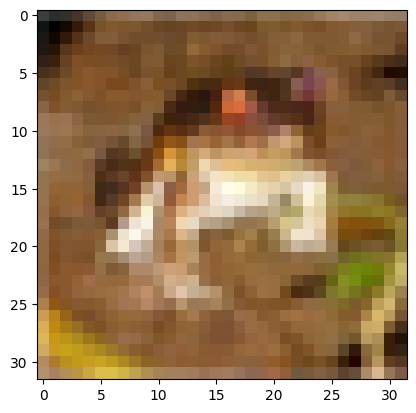

In [32]:
plt.imshow(X_train[0])
plt.show()

## 4. Data Preparation

In [9]:
X_train = X_train/255

In [10]:
X_test = X_test/255

In [11]:
#checking the max and min value
X_test.max(),X_test.min()

(np.float64(1.0), np.float64(0.0))

In [12]:
X_train.max(),X_train.min()

(np.float64(1.0), np.float64(0.0))

In [41]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

## 5. Model Building

In [38]:
model = Sequential()
model.add(layer=Flatten(input_shape=(32,32,3)))
model.add(Dense(units=100,activation='relu'))
model.add(Dense(units=50,activation='relu'))
model.add(Dense(units=10,activation='softmax'))
        

C:\Users\amrit\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['categorical_accuracy'])

## 6.  Model Training

In [45]:
model.fit(x=X_train,y=y_train,batch_size=60,epochs=10,validation_data=(X_test,y_test))

Epoch 1/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - categorical_accuracy: 0.4830 - loss: 1.4515 - val_categorical_accuracy: 0.4398 - val_loss: 1.5672
Epoch 2/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - categorical_accuracy: 0.4902 - loss: 1.4281 - val_categorical_accuracy: 0.4611 - val_loss: 1.5012
Epoch 3/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - categorical_accuracy: 0.4971 - loss: 1.4097 - val_categorical_accuracy: 0.4699 - val_loss: 1.4880
Epoch 4/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - categorical_accuracy: 0.5009 - loss: 1.4010 - val_categorical_accuracy: 0.4731 - val_loss: 1.4748
Epoch 5/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - categorical_accuracy: 0.5045 - loss: 1.3870 - val_categorical_accuracy: 0.4778 - val_loss: 1.4655
Epoch 6/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - categorical_accuracy: 0.5090 - loss: 1.3790 - val_categorical_accuracy: 0.4961 - val_loss: 1.4350
Epoch 7/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - categorical_accuracy: 0

## 7. Model Prediction

In [49]:
y_pred=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [55]:
np.argmax(y_pred[1])

np.int64(9)

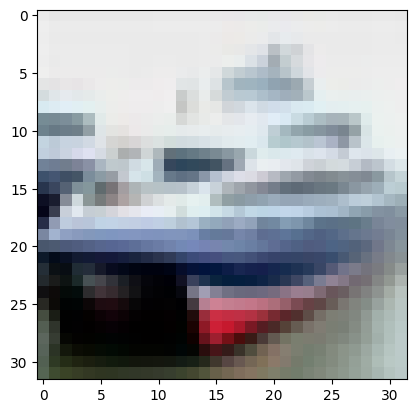

In [56]:
plt.imshow(X_test[1])

## 8. Take out the file 

In [58]:
model.save("cifar10.h5")